In [ ]:
import pandas as pd

def corriger_biais_certitude(df: pd.DataFrame,
                              vote_col: str = 'correct_answer',
                              rater_col: str = 'individual') -> pd.DataFrame:
    df = df.copy()

    certitude = df[vote_col].abs()                         # |vote| ∈ {1,2,3}
    mu_i      = certitude.groupby(df[rater_col]).transform('mean')  # µ_i par testeur
    x_i       = 2 - mu_i                                  # décalage individuel

    certitude_corrigee = (certitude + x_i)    # on reste dans [1,3]
    df[vote_col]       = certitude_corrigee * np.sign(df[vote_col])  # on remet le signe

    return df


def charger_et_corriger(chemin_csv: str) -> pd.DataFrame:
    """Charge un CSV et applique la correction en place sur correct_answer."""
    df = pd.read_csv(chemin_csv)
    return corriger_biais_certitude(df)

In [6]:
import sys 
import os
import numpy as np
import subprocess
from tqdm import tqdm
import warnings
from scipy.spatial.distance import cdist
from pathlib import Path


# 1. CHARGEMENT

print("Chargement des données...")

df_en = pd.read_csv("../../interspeech-2020-perceptimatic/DATA/english/all_aligned_clean_english.csv", sep=r"\s+") 
df_fr = pd.read_csv("../../interspeech-2020-perceptimatic/DATA/french/all_aligned_clean_french.csv", sep=r"\s+")
df_en['language'] = 'english'
df_fr['language'] = 'french'
df_items = pd.concat([df_en, df_fr])

df_tests = pd.read_csv("../../interspeech-2020-perceptimatic/DATA/human_and_models.csv", low_memory=False)
df_triplets = df_tests.drop_duplicates(subset=['filename', 'language']).copy()

print("Données chargées.")



# DOSSIERS DE SAUVEGARDE 
SAVE_DIR = Path().resolve() / "matrices_mfcc_sauvegardees"

chemin_csv_gow = Path("matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv")
chemin_csv_pow = Path("matrices_mfcc_sauvegardees/resultats_pow_WO_OT.csv")
df_final = charger_et_corriger(chemin_csv_gow)
df_final2 = charger_et_corriger(chemin_csv_pow)

# Corrélations et moyennes (sur df_final, niveau participant)
corr_gow_mfcc  = df_final['Delta_Machine_GOW'].corr(df_final['Delta_Machine_DTW_PERSO'])
corr_dtw_mfcc  = df_final['Delta_Machine_DTW_PERSO'].corr(df_final['MFCC'])
corr_pow_mfcc  = df_final2['Delta_Machine_POW'].corr(df_final2['Delta_Machine_DTW_PERSO'])
corr_gow_pow   = df_final['Delta_Machine_GOW'].corr(df_final2['Delta_Machine_POW'])




Chargement des données...
Données chargées.


In [7]:
# AFFICHAGE

print(f"Corrélation (POW vs DTW Perso) : {corr_pow_mfcc:.4f}")
print(f"Corrélation (DTW Perso vs DTW Papier)    : {corr_dtw_mfcc:.4f}")
print(f"Corrélation (GOW vs DTW Perso) : {corr_gow_mfcc:.4f}")
print(f"Corrélation (GOW vs POW) : {corr_gow_pow:.4f}")

Corrélation (POW vs DTW Perso) : 0.9196
Corrélation (DTW Perso vs DTW Papier)    : 0.9992
Corrélation (GOW vs DTW Perso) : 0.8416
Corrélation (GOW vs POW) : 0.9124


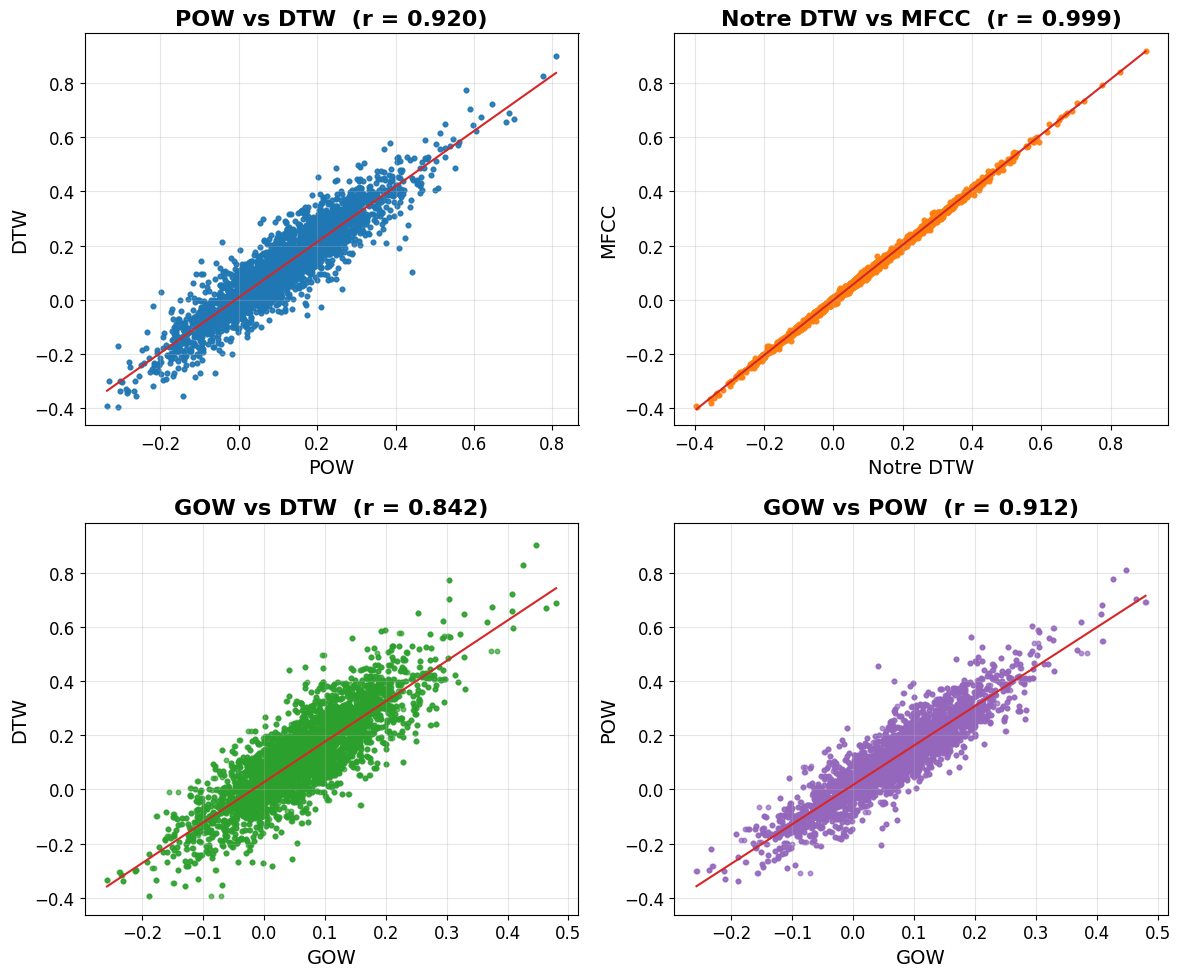

In [8]:
import matplotlib.pyplot as plt


# Les 4 paires de corrélation calculées plus haut
paires = [
    ("POW", df_final2['Delta_Machine_POW'], "DTW", df_final['Delta_Machine_DTW_PERSO'], corr_pow_mfcc),
    ("Notre DTW", df_final['Delta_Machine_DTW_PERSO'], "MFCC", df_final['MFCC'], corr_dtw_mfcc),
    ("GOW", df_final['Delta_Machine_GOW'], "DTW", df_final['Delta_Machine_DTW_PERSO'], corr_gow_mfcc),
    ("GOW", df_final['Delta_Machine_GOW'], "POW", df_final2['Delta_Machine_POW'], corr_gow_pow),
]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
# agrandissement global des polices
plt.rcParams.update({
    'font.size':        14,   # base
    'axes.titlesize':   16,   # titres des sous-graphes
    'axes.labelsize':   14,   # labels x/y
    'xtick.labelsize':  12,   # graduations x
    'ytick.labelsize':  12,   # graduations y
})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Calcul du min/max global sur l'axe Y pour harmoniser les échelles
y_min_global = min(pd.Series(y).dropna().min() for _, _, _, y, _ in paires)
y_max_global = max(pd.Series(y).dropna().max() for _, _, _, y, _ in paires)
y_margin = (y_max_global - y_min_global) * 0.05

for i, (ax, (nom_x, x, nom_y, y, r)) in enumerate(zip(axes, paires)):
    sous_df = pd.DataFrame({nom_x: x, nom_y: y}).dropna()

    ax.scatter(sous_df[nom_x], sous_df[nom_y], alpha=0.3, s=10, color=colors[i])

    # Droite de régression
    coeffs = np.polyfit(sous_df[nom_x], sous_df[nom_y], 1)
    x_ligne = np.linspace(sous_df[nom_x].min(), sous_df[nom_x].max(), 100)
    ax.plot(x_ligne, np.polyval(coeffs, x_ligne), color='tab:red', linewidth=1.5)

    # Échelle Y commune à tous les sous-graphes
    ax.set_ylim(y_min_global - y_margin, y_max_global + y_margin)

    ax.set_xlabel(nom_x)
    ax.set_ylabel(nom_y)
    ax.set_title(f"{nom_x} vs {nom_y}  (r = {r:.3f})", fontsize=16, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()